# LDA
- Liad Mandil, 315096073
- Maxim Prokopchuk, 337875397

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_val_score

--------------------------

## Helpfull code

---------------------------------------

## Load Data

In [2]:
spaceship_data = pd.read_csv('final_data.csv')

## split to x and y

In [3]:
y = spaceship_data["Transported"].astype(int)
X = spaceship_data.drop(columns=["Transported", "GroupId", "GroupMemberId"])

-----------------------

## Train-Test Split

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

-------------------

## LDA Model

In [6]:
lda_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LDA(solver="svd"))
])

lda_pipe.fit(x_train, y_train)

lda_cv_score = np.mean(
    cross_val_score(
        lda_pipe,
        x_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )
)

print("LDA CV accuracy:", lda_cv_score)

LDA CV accuracy: 0.7652989821543776


## Result

In [7]:
y_pred_lda_train = lda_pipe.predict(x_train)
y_score_lda_train = lda_pipe.predict_proba(x_train)[:, 1]

אחוז דיוק על test

In [8]:
train_acc_lda = accuracy_score(y_train, y_pred_lda_train)

In [9]:
print("="*40)
print("LDA — TRAIN PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc_lda*100:.2f}%")
print("="*40)

LDA — TRAIN PERFORMANCE
Accuracy : 76.63%


In [10]:
cv_scores = cross_val_score(
    lda_pipe,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

summary = pd.DataFrame({
    "model": ["LDA (svd)"],
    "mean_cv_accuracy": [cv_scores.mean()],
    "std_cv_accuracy": [cv_scores.std()]
})

summary

,model,mean_cv_accuracy,std_cv_accuracy
0,LDA (svd),0.766324,0.010089


מטריצת ערבול למודל המוצלח ביותר TRAIN

In [11]:
print(f"QDA Train Accuracy: {train_acc_lda*100:.2f}%")


QDA Train Accuracy: 76.63%


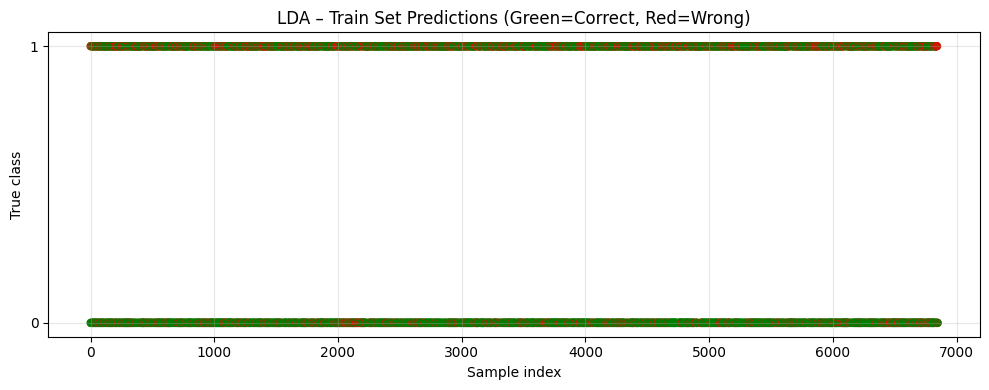

Accuracy: 76.63%
Errors: 1600 / 6847


In [12]:
correct = (y_pred_lda_train == y_train)

# צבעים: ירוק לנכון, אדום לשגוי
colors = np.where(correct, "green", "red")

plt.figure(figsize=(10,4))
plt.scatter(range(len(y_train)), y_train, c=colors, s=25, alpha=0.7)

plt.yticks([0,1])
plt.xlabel("Sample index")  
plt.ylabel("True class")
plt.title("LDA – Train Set Predictions (Green=Correct, Red=Wrong)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()      

print(f"Accuracy: {100*np.mean(correct):.2f}%")
print(f"Errors: {np.sum(~correct)} / {len(correct)}")

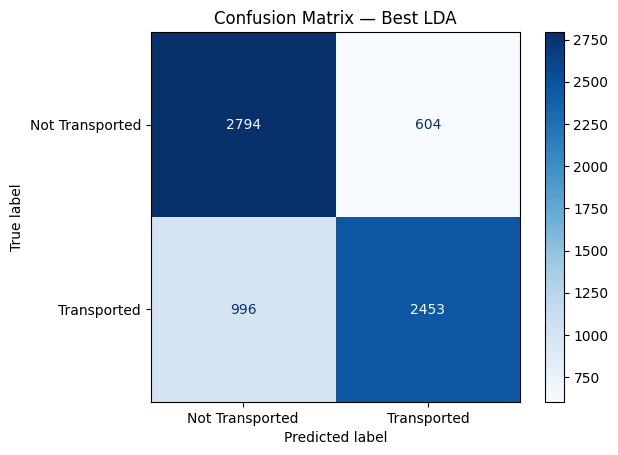

In [13]:
ConfusionMatrixDisplay.from_estimator(
    lda_pipe,
    x_train,
    y_train,
    display_labels=["Not Transported", "Transported"],
    cmap="Blues"
)

plt.title("Confusion Matrix — Best LDA")
plt.grid(False)
plt.show()